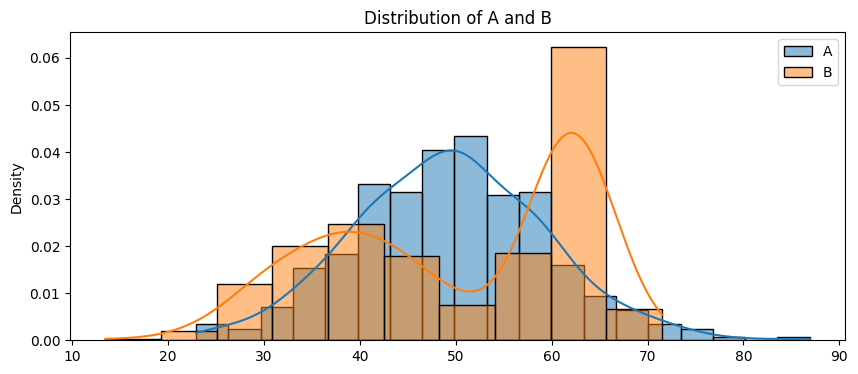

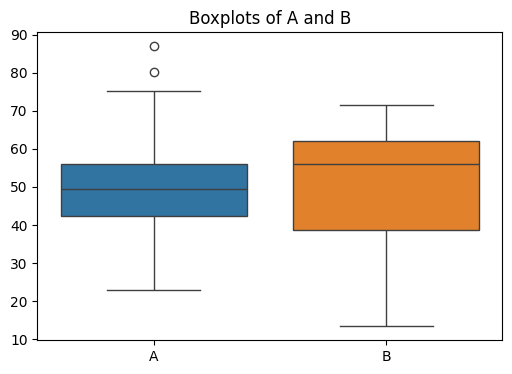

Mann-Whitney U result: p-value = 0.013, Cohen's d = -0.084
Yes


In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu

# Load data
df = pd.read_csv("input_data/data.csv")

# Verify required columns
if not {"A", "B"}.issubset(df.columns):
    raise ValueError("Columns A and B must be present in the CSV.")

a = df["A"].dropna().to_numpy()
b = df["B"].dropna().to_numpy()

# Minimum sample size check
if a.size < 2 or b.size < 2:
    raise ValueError("Need at least 2 non‑NaN values in each group.")

# Descriptive statistics
desc = {
    "A_n": int(a.size),
    "A_mean": float(np.mean(a)),
    "A_median": float(np.median(a)),
    "A_std": float(np.std(a, ddof=1)),
    "B_n": int(b.size),
    "B_mean": float(np.mean(b)),
    "B_median": float(np.median(b)),
    "B_std": float(np.std(b, ddof=1)),
}

# Plots
plt.figure(figsize=(10, 4))
sns.histplot(a, color="C0", label="A", stat="density", kde=True, alpha=0.5)
sns.histplot(b, color="C1", label="B", stat="density", kde=True, alpha=0.5)
plt.legend()
plt.title("Distribution of A and B")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(data=[a, b])
plt.xticks([0, 1], ["A", "B"])
plt.title("Boxplots of A and B")
plt.show()

# Assumption checks
def shapiro_p(x):
    if 3 <= x.size <= 5000:
        _, p = shapiro(x)
        return p
    return None

p_a = shapiro_p(a)
p_b = shapiro_p(b)
levene_stat, levene_p = levene(a, b, center="median")

# Choose appropriate test
alpha = 0.05
if (p_a is None or p_a > alpha) and (p_b is None or p_b > alpha):
    equal_var = levene_p >= alpha
    t_stat, p_val = ttest_ind(a, b, equal_var=equal_var)
    test_used = "Welch t-test" if not equal_var else "Student t-test"
    test_stat = float(t_stat)
else:
    u_stat, p_val = mannwhitneyu(a, b, alternative="two-sided")
    test_used = "Mann-Whitney U"
    test_stat = float(u_stat)

# Effect size (Cohen's d)
mean_diff = np.mean(a) - np.mean(b)
s_a = np.std(a, ddof=1)
s_b = np.std(b, ddof=1)
n_a, n_b = a.size, b.size
pooled_sd = (
    np.sqrt(((n_a - 1) * s_a ** 2 + (n_b - 1) * s_b ** 2) / (n_a + n_b - 2))
    if (n_a + n_b) > 2
    else np.nan
)
cohen_d = mean_diff / pooled_sd if pooled_sd > 0 else np.nan

significant = p_val < alpha

# Save diagnostics
os.makedirs("/display_output", exist_ok=True)
diag_path = "/display_output/diagnostics.txt"
with open(diag_path, "w") as f:
    f.write("Descriptive statistics:\n")
    for k, v in desc.items():
        f.write(f"{k}: {v}\n")
    f.write("\nAssumption tests:\n")
    f.write(f"Shapiro p (A): {p_a}\n")
    f.write(f"Shapiro p (B): {p_b}\n")
    f.write(f"Levene p: {levene_p}\n")
    f.write("\nTest details:\n")
    f.write(f"Test used: {test_used}\n")
    f.write(f"Test statistic: {test_stat}\n")
    f.write(f"P-value: {p_val}\n")
    f.write(f"Cohen's d: {cohen_d}\n")
    f.write(f"Significant (alpha={alpha}): {significant}\n")

# Write final Yes/No result
final_path = "/display_output/final_result.txt"
with open(final_path, "w") as f:
    f.write("Yes" if significant else "No")

# Second‑last print: description of result
print(f"{test_used} result: p-value = {p_val:.4g}, Cohen's d = {cohen_d:.3f}")

# Last print: final answer only
print("Yes" if significant else "No")
